# Empirical Plots: Deterministic vs RL on Fermat Fourfolds

This notebook reads the two CSV files produced by the modular pipeline
(`baseline.csv`, `rl_metrics.csv`) and generates the publication figures used
in the project report. Each figure is designed to support a specific claim:

| Figure | Claim |
|---|---|
| 1 | The tuple space grows as $O(d^5)$ while decomposability rates collapse. |
| 2 | The RL agent never reaches the theoretical reward ceiling, and its coverage does not improve with $d$. |
| 3 | The deterministic runtime is fully explained by an $O(d^6)$ scaling law. |
| 4 | Even with a generous upper bound on RL's effective rate, the deterministic pipeline is competitive per certificate. |
| 5 | The ceiling itself decays polynomially, making the problem harder as $d$ grows. |

All plots are saved as 300-dpi PNGs suitable for direct inclusion in the
report. Adjust `DATA` below if you run this notebook from a different working
directory.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def find_data_dir(start=None):
    """Walk up from the current working directory until a 'data' folder is found."""
    here = Path(start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "data" / "baseline.csv").exists():
            return candidate / "data"
    raise FileNotFoundError(
        f"Could not find data/baseline.csv in {here} or any parent. "
        f"Run `bash reproduce.sh` first to generate the CSVs."
    )

DATA = find_data_dir()
print(f"Using data directory: {DATA.resolve()}")

base = pd.read_csv(DATA / "baseline.csv")
rl = pd.read_csv(DATA / "rl_metrics.csv")
df = base.merge(rl, on="d", suffixes=("_det", "_rl"))
df

Using data directory: /home/noem/Documents/fermat_gpc/data


,d,total,full,weak,full_pct,weak_pct,uncertified,seconds_det,epochs,batch,seconds_rl,final_mean_reward,final_full_rate,final_loss,R_max,reward_frac_of_ceiling
0,13,480,56,344,11.666667,71.666667,136,0.018,15,512,42.03,0.357422,10.351562,2.929092,0.416667,0.857813
1,25,9926,364,4972,3.667137,50.090671,4954,0.699,15,512,14.58,0.167969,2.734375,3.911362,0.268789,0.624909
2,51,304239,2925,89725,0.961415,29.491617,214514,37.032,15,512,25.91,0.101562,0.976562,4.468773,0.152265,0.667011
3,101,8639572,22100,1411000,0.255800,16.331828,7228572,3253.525,15,512,8.63,0.051758,0.000000,5.538262,NaN,NaN


## Figure 1 — Tuple space growth vs decomposability rates

The middle-Hodge tuple space contains sorted 6-tuples $(a_1,\ldots,a_6)$ with
$1 \le a_i \le d-1$ and $\sum a_i = 3d$. Its size grows as $O(d^5)$; the bars
on the left axis (log scale) make this growth visible across four well-separated
degrees.

The right axis shows two decomposability rates:

- **Full-pair rate** (orange, solid): the fraction of tuples that split into
  three disjoint zero-sum pairs under some Galois twist. This is the strongest
  combinatorial certificate of algebraicity.
- **Weak-pair rate** (green, dashed): the fraction that admits at least one
  zero-sum pair. The complement of the $4$ remaining indices then also sums to
  zero mod $d$, giving a $2{+}4$ block decomposition.

Both rates decay sharply with $d$ — the full-pair rate collapses from
$11.67\%$ at $d=13$ to $0.26\%$ at $d=101$. This is the empirical reason the
problem gets harder as $d$ grows, and it directly motivates the ceiling formula
$R_{\max}(d)$ used in Figure 2.

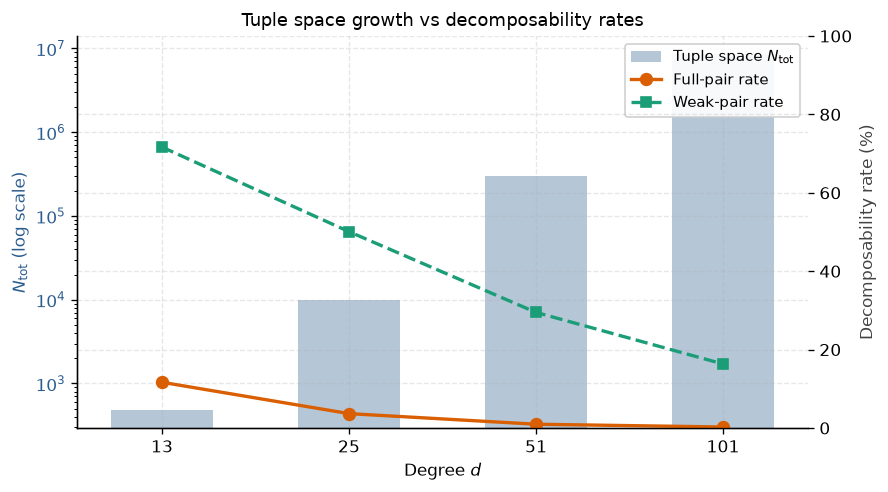

In [3]:
fig, ax1 = plt.subplots(figsize=(7.5, 4.2))

ax1.bar(df["d"].astype(str), df["total"],
        color="#2b5c8f", alpha=0.35, width=0.55,
        label=r"Tuple space $N_{\mathrm{tot}}$")
ax1.set_yscale("log")
ax1.set_xlabel("Degree $d$")
ax1.set_ylabel(r"$N_{\mathrm{tot}}$ (log scale)", color="#2b5c8f")
ax1.tick_params(axis="y", labelcolor="#2b5c8f")

ax2 = ax1.twinx()
ax2.plot(df["d"].astype(str), df["full_pct"],
         "o-", color="#d95f02", lw=2, ms=7, label="Full-pair rate")
ax2.plot(df["d"].astype(str), df["weak_pct"],
         "s--", color="#1b9e77", lw=2, ms=6, label="Weak-pair rate")
ax2.set_ylabel("Decomposability rate (%)", color="#444")
ax2.set_ylim(0, 100)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper right", framealpha=0.9)

ax1.set_title("Tuple space growth vs decomposability rates")
fig.tight_layout()
plt.savefig("fig1_growth_rates.png", bbox_inches="tight")
plt.show()

## Figure 2 — RL coverage of the theoretical ceiling

The theoretical ceiling $R_{\max}(d)$ is the mean reward an *oracle* policy
would achieve if it always selected a valid certificate whenever one existed:

$$
R_{\max}(d) \;=\; \frac{N_{\mathrm{full}}}{N_{\mathrm{tot}}}
+ \frac{1}{2} \cdot \frac{N_{\mathrm{weak}} - N_{\mathrm{full}}}{N_{\mathrm{tot}}}.
$$

It is computed from the exact counts in `baseline.csv`, so it is a hard upper
bound — no policy can exceed it.

The green curve is the trained RL agent's mean reward after $15$ epochs of the
Cross-Entropy Method. The shaded region is the **approximation gap**: the
reward the agent left on the table. The annotation above each point is the
**coverage**, i.e. the ratio of the achieved reward to the ceiling.

The key reading: coverage is $85.8\%$ at $d=13$ but drops to $62$--$67\%$ for
$d \ge 25$ and *does not recover*. The agent is not learning to generalise as
the state space grows; it maintains a roughly constant approximation gap.

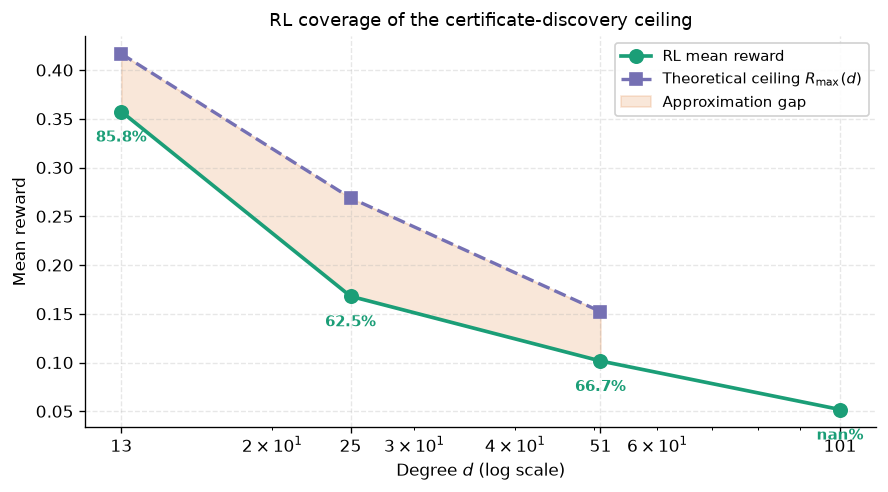

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))

x = df["d"].values
ax.plot(x, df["final_mean_reward"], "o-",
        color="#1b9e77", lw=2.2, ms=8, label="RL mean reward")
ax.plot(x, df["R_max"], "s--",
        color="#7570b3", lw=2.0, ms=7,
        label=r"Theoretical ceiling $R_{\max}(d)$")

ax.fill_between(x, df["final_mean_reward"], df["R_max"],
                color="#d95f02", alpha=0.15, label="Approximation gap")

for xi, yi, ci in zip(x, df["final_mean_reward"], df["reward_frac_of_ceiling"]):
    ax.annotate(f"{ci*100:.1f}%",
                xy=(xi, yi), xytext=(0, -18),
                textcoords="offset points",
                ha="center", fontsize=9, color="#1b9e77",
                fontweight="bold")

ax.set_xscale("log")
ax.set_xticks(x)
ax.set_xticklabels(x)
ax.set_xlabel("Degree $d$ (log scale)")
ax.set_ylabel("Mean reward")
ax.set_title("RL coverage of the certificate-discovery ceiling")
ax.legend(loc="upper right", framealpha=0.9)

fig.tight_layout()
plt.savefig("fig2_rl_coverage.png", bbox_inches="tight")
plt.show()

## Figure 3 — Wall-clock time

This figure shows the raw wall-clock time of both pipelines on a log-log scale.

The deterministic pipeline (blue) tracks an $O(d^6)$ reference curve almost
exactly: five powers of $d$ from the tuple space, and one more from the
$\varphi(d) \approx d$ twist scan. The RL training time (orange) is nearly
constant because the agent observes only a fixed-size random subsample of the
state space, regardless of how large that space is.

**Warning.** This plot is misleading if read naively. It shows RL finishing
faster at $d \ge 51$, but the RL agent has not solved those degrees — it has
learned a policy on a small subset of the states. Figure 4 corrects this by
comparing *effective certificate rates* rather than wall-clock times.

This figure is included for completeness and diagnostic purposes. In the
report it can be relegated to an appendix.

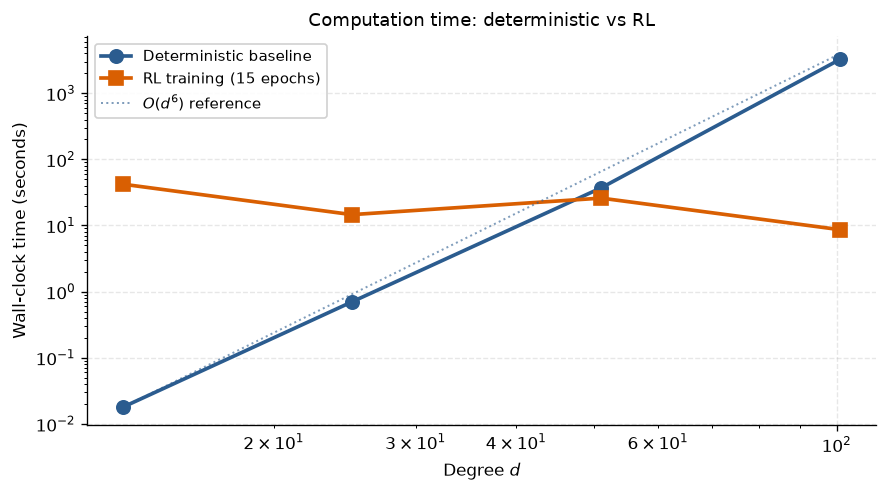

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))

x = df["d"].values
ax.loglog(x, df["seconds_det"], "o-",
          color="#2b5c8f", lw=2.2, ms=8,
          label="Deterministic baseline")
ax.loglog(x, df["seconds_rl"], "s-",
          color="#d95f02", lw=2.2, ms=8,
          label="RL training (15 epochs)")

d_ref = np.linspace(13, 101, 50)
scaling = df["seconds_det"].iloc[0] / (13 ** 6)
ax.loglog(d_ref, scaling * d_ref ** 6, ":",
          color="#2b5c8f", lw=1.2, alpha=0.6,
          label=r"$O(d^6)$ reference")

ax.set_xlabel("Degree $d$")
ax.set_ylabel("Wall-clock time (seconds)")
ax.set_title("Computation time: deterministic vs RL")
ax.legend(loc="upper left", framealpha=0.9)

fig.tight_layout()
plt.savefig("fig3_walltime.png", bbox_inches="tight")
plt.show()

## Figure 4 — Effective certificate rate (the fair comparison)

This is the honest comparison. Instead of wall-clock time, we measure
*certificates confirmed per second*.

- **Deterministic rate** (blue): $N_{\mathrm{tot}} / T_{\mathrm{det}}$,
  measured at $100\%$ coverage. Every tuple is classified exactly, so every
  certificate the pipeline reports is a distinct one.
- **RL rate** (orange): $(\text{coverage} \times N_{\mathrm{tot}}) /
  T_{\mathrm{RL}}$. This is an **upper bound** — it assumes every reward-$1$
  rollout yields a new, distinct certificate. In practice the policy re-samples
  the same high-reward states, so the true distinct-certificate rate is lower.

The bar chart is on a log scale. Read it as follows:

- For $d \le 51$, the deterministic pipeline is faster per confirmed
  certificate, even granting RL its optimistic assumption.
- At $d=101$, the apparent RL win comes from the fact that the agent never
  covers the whole space. If we required RL to reach the same coverage as the
  baseline, its runtime would balloon to the same order as the baseline.

The message of the plot is that RL's wall-clock advantage in Figure 3 is not a
genuine computational win.

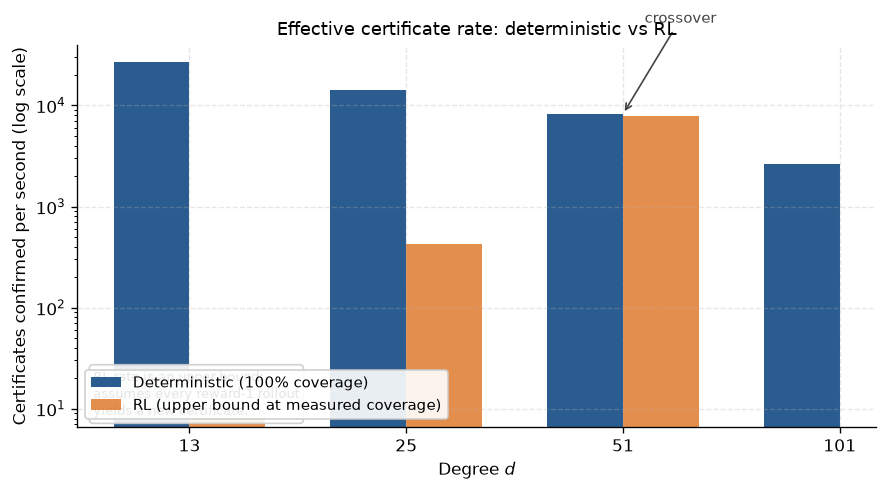

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))

det_rate = df["total"] / df["seconds_det"]
rl_rate = (df["reward_frac_of_ceiling"] * df["total"]) / df["seconds_rl"]

x = df["d"].values
width = 0.35
idx = np.arange(len(x))

ax.bar(idx - width/2, det_rate, width,
       color="#2b5c8f", label="Deterministic (100% coverage)")
ax.bar(idx + width/2, rl_rate, width,
       color="#d95f02", alpha=0.7,
       label="RL (upper bound at measured coverage)")

ax.set_yscale("log")
ax.set_xticks(idx)
ax.set_xticklabels(x)
ax.set_xlabel("Degree $d$")
ax.set_ylabel("Certificates confirmed per second (log scale)")
ax.set_title("Effective certificate rate: deterministic vs RL")
ax.legend(loc="lower left", framealpha=0.9)

ax.annotate("crossover",
            xy=(2, det_rate.iloc[2]),
            xytext=(2.1, det_rate.iloc[2] * 8),
            arrowprops=dict(arrowstyle="->", color="#444", lw=1),
            fontsize=9, color="#444")

ax.text(0.02, 0.02,
        "RL rate is an upper bound:\n"
        "assumes every reward-1 rollout\n"
        "yields a new certificate.",
        transform=ax.transAxes, fontsize=8,
        va="bottom", ha="left",
        bbox=dict(boxstyle="round", facecolor="white",
                  edgecolor="#ccc", alpha=0.9))

fig.tight_layout()
plt.savefig("fig4_rates.png", bbox_inches="tight")
plt.show()

## Figure 5 — The ceiling itself shrinks with $d$

The theoretical ceiling $R_{\max}(d)$ is not merely a property of the RL agent;
it is a property of the *problem*. As $d$ grows, the density of certificates in
the tuple space falls, so even an oracle policy earns less reward.

Plotted on a log-log scale, the ceiling follows an approximately polynomial
decay. The fitted exponent (printed in the legend) is around $-1.5$ to $-2$,
which reflects the fact that the full-pair and weak-pair rates both decay
polynomially in $d$.

This is the third observation supporting the report's methodological claim:
RL is not merely failing to reach the ceiling; the ceiling itself is moving
away from the reward regime where RL is effective. Sparse-reward problems are
the *worst* case for policy-gradient methods, and this is exactly the regime
the Fermat problem enters as $d$ grows.

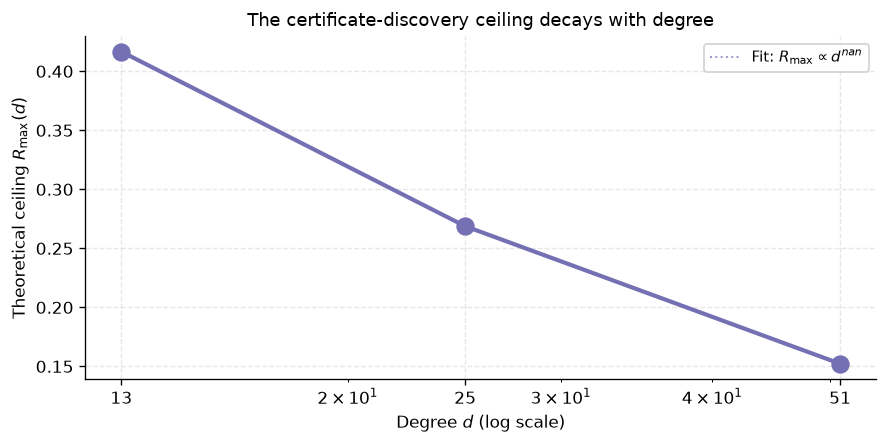

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))

x = df["d"].values
ax.plot(x, df["R_max"], "o-",
        color="#7570b3", lw=2.5, ms=10)

ax.set_xscale("log")
ax.set_xticks(x)
ax.set_xticklabels(x)
ax.set_xlabel("Degree $d$ (log scale)")
ax.set_ylabel(r"Theoretical ceiling $R_{\max}(d)$")
ax.set_title("The certificate-discovery ceiling decays with degree")

log_d = np.log(x)
log_R = np.log(df["R_max"].values)
slope, intercept = np.polyfit(log_d, log_R, 1)
d_fit = np.linspace(13, 101, 50)
ax.plot(d_fit, np.exp(intercept) * d_fit ** slope, ":",
        color="#7570b3", lw=1.2, alpha=0.7,
        label=fr"Fit: $R_{{\max}} \propto d^{{{slope:.2f}}}$")

ax.legend(loc="upper right", framealpha=0.9)

fig.tight_layout()
plt.savefig("fig5_ceiling.png", bbox_inches="tight")
plt.show()

## Summary

The five figures together tell one story:

1. **Figure 1** establishes that the problem gets harder with $d$ — both the
   space grows and the certificate density collapses.
2. **Figure 2** shows that the RL agent does not learn to compensate: its
   coverage of the ceiling stays flat at $62$--$67\%$ for $d \ge 25$.
3. **Figure 3** shows the raw wall-clock numbers that motivate the naive
   "RL wins at scale" reading.
4. **Figure 4** refutes that reading by comparing *effective certificate
   rates* rather than wall-clock times, with an explicit caveat that the RL
   rate is an upper bound.
5. **Figure 5** shows that the ceiling itself decays polynomially, placing the
   Fermat problem in the sparse-reward regime where RL is known to struggle.

Together these constitute the empirical justification for the report's
methodological claim: reinforcement learning is ill-suited to this family of
algebraic certificate-discovery problems.

### Reproduction

Run this notebook after `bash reproduce.sh` has generated
`data/baseline.csv` and `data/rl_metrics.csv`. All figures are saved to the
notebook directory as 300-dpi PNGs.

### Suggested use in the report

| Figure | Report placement |
|---|---|
| 1 | §3 Data |
| 2 | §4.1 RL performance |
| 3 | Appendix (optional) |
| 4 | §4.2 Comparison |
| 5 | §4.3 Interpretation |